In [ ]:
import os, sys, yaml
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "python_scripts" else Path.cwd().parents[1]
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stu"])
if "useful_stuff_path" in paths:
    sys.path.append(paths["useful_stuff_path"])


In [21]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    signal_RDM_metric: str = "correlation"
    model_RDM_metric: str = "correlation"
    model_name: str = "vit_l_16"
    img_size: int = 384
    new_fs: int = 100
    pkg: str = "timm"
    results_dir: Path = Path(paths["data_path"]) / "results"
    cmap_name: str = "plasma"
    line_width: float = 2.0
    alpha: float = 0.9

cfg = Cfg()
cfg


Cfg(monkey_name='three0', date='250313', brain_area='AIT', signal_RDM_metric='correlation', model_RDM_metric='correlation', model_name='vit_l_16', img_size=384, new_fs=100, pkg='timm', results_dir=PosixPath('/Users/tizianocausin/metrics_II_local/results'), cmap_name='plasma', line_width=2.0, alpha=0.9)

In [22]:
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
print(f"{len(layers)} layers")


24 layers


In [23]:
def static_drsa_save_name(layer_name):
    return cfg.results_dir / f"static_dRSA_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{layer_name}_{cfg.new_fs}Hz.npz"

curves = {}
missing = []
for layer_name in layers:
    save_name = static_drsa_save_name(layer_name)
    if save_name.exists():
        curves[layer_name] = np.load(save_name)["arr_0"]
    else:
        missing.append(save_name)

if not curves:
    raise FileNotFoundError(f"No static dRSA files found in {cfg.results_dir}")

print(f"loaded {len(curves)} / {len(layers)} layers")
if missing:
    print(f"missing {len(missing)} files")
    for save_name in missing[:5]:
        print(save_name)


loaded 24 / 24 layers


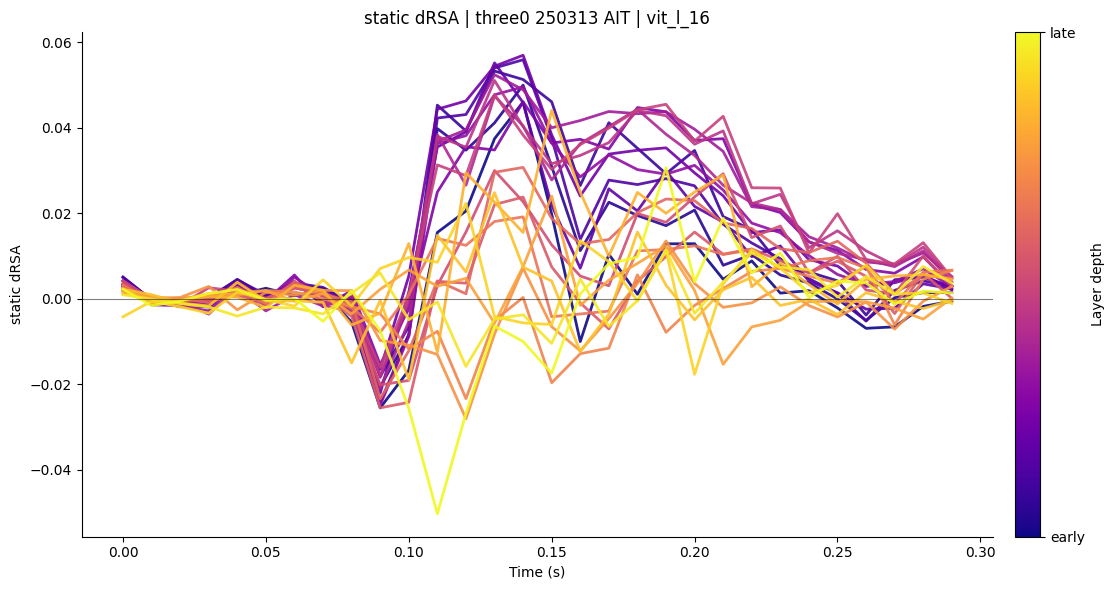

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
cmap = mpl.colormaps[cfg.cmap_name]
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

for i, layer_name in enumerate(layers):
    if layer_name not in curves:
        continue
    drsa = curves[layer_name]
    t = np.arange(len(drsa)) / cfg.new_fs
    ax.plot(
        t,
        drsa,
        color=cmap(norm(i)),
        linewidth=cfg.line_width,
        alpha=cfg.alpha,
        label=layer_name,
    )

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Layer depth")
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels(["early", "late"])

ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("static dRSA")
ax.set_title(f"static dRSA | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name}")
ax.spines[["top", "right"]].set_visible(False)
if len(curves) <= 12:
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
